Pre-processing the dataset:

In [8]:
import time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import HashingVectorizer
from scipy.sparse import hstack

DATASET_PATH = "../datasets"
df = pd.read_csv(f"{DATASET_PATH}/labeled_data/final_training_dataset_ready.csv")

valuable_exts = [
        # IT / Secrets
        ".pem", ".key", ".kdbx", ".p12", ".ovpn", ".private", ".wallet", 
        ".asc", ".gpg", ".sql", ".env", ".json", ".yml", ".yaml", 
        # Finance
        ".xlsx", ".xls", ".csv", ".pdf", 
        # HR
        ".docx", ".doc", ".rtf"
    ]

# todo: recency score - figure out a good balance
df["recency_score"] = 1 / ((time.time() - df["mod_time_unix"]) / (90 * 24 * 3600) + 1)
df["size_logged"] = np.log1p(df["size_bytes"])
df["name_len"] = df["filename"].apply(len)
df["path_len"] = df["path"].apply(len)

# todo: change to more nuanced scoring/hashing
df["valuable_ext"] = (
    df["extension"]
    .isin(valuable_exts)
    .astype(int)
)

# Initialize HashingVectorizer
hashing_vectorizer = HashingVectorizer(
    n_features=1024,
    analyzer="char",
    norm=None,
    alternate_sign=False,
    ngram_range=(3, 3),
)

# Apply feature hashing to the 'filename' column
filename_vectors = hashing_vectorizer.fit_transform(df["filename"])
path_vectors = hashing_vectorizer.fit_transform(df["path"])

# # Dropping original columns after they've been used for feature creation
# df.drop(
#     ["filename", "path", "extension", "size_bytes", "mod_time_unix"],
#     axis=1,
#     inplace=True,
# )

numerical_features = df[["recency_score", "size_logged", "valuable_ext", "name_len", "path_len"]].values
X = hstack([numerical_features, filename_vectors, path_vectors])
y = df["label_finance"].values

In [9]:
df.to_csv("1.csv", index=False)

In [10]:
# Convert the first 5 rows to a dense array
X_sample_dense = X.toarray()

# To make it more readable, let's put it into a DataFrame, although this is only for display purposes
# as X itself is a sparse matrix.
num_numerical_features = numerical_features.shape[1]
num_filename_features = filename_vectors.shape[1]
num_path_features = path_vectors.shape[1]

# Create column names for better readability
column_names = (
    ["recency_score", "size_logged","name_len", "path_len", "valuable_ext"]
    + [f"filename_hash_{i}" for i in range(num_filename_features)]
    + [f"path_hash_{i}" for i in range(num_path_features)]
)

# Display the sample as a DataFrame
X_sample_df = pd.DataFrame(X_sample_dense, columns=column_names)
display(X_sample_df.sort_values(by="recency_score", ascending=False))

,recency_score,size_logged,name_len,path_len,valuable_ext,filename_hash_0,filename_hash_1,filename_hash_2,filename_hash_3,filename_hash_4,...,path_hash_1014,path_hash_1015,path_hash_1016,path_hash_1017,path_hash_1018,path_hash_1019,path_hash_1020,path_hash_1021,path_hash_1022,path_hash_1023
2765,0.995081,9.124347,0.0,176.0,165.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
525,0.994665,9.738023,1.0,126.0,20.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2995,0.980132,10.463732,1.0,181.0,54.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2071,0.973680,10.740605,0.0,171.0,20.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1331,0.967080,10.300215,0.0,164.0,83.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2237,0.019333,11.742687,0.0,17.0,55.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1744,0.019189,12.090987,1.0,11.0,15.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1764,0.018851,14.405268,0.0,14.0,40.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
692,0.018765,12.435830,0.0,10.0,37.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Training:

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split Data
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)

# Train Model
model = LogisticRegression(solver="lbfgs", max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
y_scores = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9286871961102107

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96       556
           1       0.76      0.41      0.53        61

    accuracy                           0.93       617
   macro avg       0.85      0.70      0.75       617
weighted avg       0.92      0.93      0.92       617



In [15]:
results = pd.DataFrame({
    'filepath': df.loc[idx_test]['path'].values,
    'filename': df.loc[idx_test]['filename'].values,
    'extension': df.loc[idx_test]['extension'].values,
    'size_bytes': df.loc[idx_test]['size_bytes'].values,
    'name_len': df.loc[idx_test]['name_len'].values,
    'path_len': df.loc[idx_test]['path_len'].values,
    'mod_time_unix': df.loc[idx_test]['mod_time_unix'].values,
    'actual_label': y_test,
    'model_score': y_scores
})

# Sort and slice the results
sorted_results = results.sort_values(by='model_score', ascending=False)
sorted_results[:20]

,filepath,filename,extension,size_bytes,name_len,path_len,mod_time_unix,actual_label,model_score
583,\\wsl$\Ubuntu\home\mcallahan\projects\linuxkit...,loadbalancerloadbalancingrules.go,.go,10169,33,145,1.685451e+09,1,0.999947
479,C:\Users\daniel71\Dev\axelor-business-suite\ax...,RefundInvoice.java,.java,3291,18,130,1.672869e+09,1,0.999939
500,C:\Users\db_admin\source\repos\aws-sdk-java\aw...,AddRoleToInstanceProfileResultStaxUnmarshaller...,.java,2365,51,132,1.693447e+09,1,0.999581
351,C:\Work\Projects\gfirev2\src\GFire\InvoiceBund...,InvoiceInterface.php,.php,87,20,66,1.684516e+09,1,0.997110
125,C:\Users\martin05\Dev\aws-sdk-cpp\aws-cpp-sdk-...,CreateLoadBalancerRequest.h,.h,29809,27,109,1.732575e+09,1,0.996923
13,C:\Users\boothtonya\Desktop\Coding\project0\ve...,TaxRuleRepositoryInterfaceTest.php,.php,23456,34,123,1.732274e+09,1,0.994489
197,C:\Users\tara56\AppData\Local\Temp\git\aws-sdk...,PasswordPolicyStaxUnmarshaller.java,.java,5283,35,140,1.678712e+09,1,0.994356
214,C:\Users\paul26\source\repos\terraform-provide...,resource_aws_load_balancer_backend_server_poli...,.go,4213,51,55,1.709162e+09,1,0.988223
216,C:\Users\thomas35\Desktop\Code_Review\obma\htd...,OpenCloud.LoadBalancer.Service.html,.html,92842,35,92,1.692263e+09,1,0.986716
584,D:\Websites\kafka\public_html\clients\src\main...,ConsumerRebalanceCallback.java,.java,5998,30,85,1.680699e+09,1,0.984344


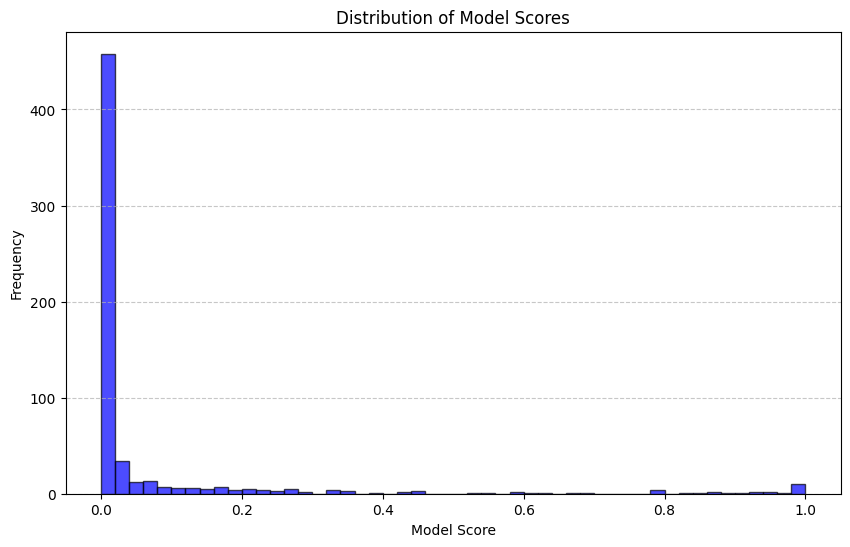

In [13]:
import matplotlib.pyplot as plt

# Plot the distribution of model scores
plt.figure(figsize=(10, 6))
plt.hist(sorted_results['model_score'], bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of Model Scores')
plt.xlabel('Model Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Exporting weights:

In [14]:
import os

def export_model_to_cpp(model, output_path="include/Weights.h"):
    """
    Exports sklearn LogisticRegression weights to a C++ header file.
    """
    # Extract Parameters
    bias = model.intercept_[0]
    weights = model.coef_.flatten()

    # Format the Content
    cpp_content =f"""
#pragma once
// AUTOMATICALLY GENERATED FILE 
// Weights Count: {len(weights)}

#include <vector>
#include <unordered_set>
#include <string>

const double MODEL_BIAS = {bias:.10f};

const std::vector<double> MODEL_WEIGHTS = {{
{', '.join([f'{w:.10f}' for w in weights])}}};

const std::unordered_set<std::wstring> HIGH_VAL_EXTS = {{
    {', '.join([f'L"{ext}"' for ext in valuable_exts])}}};
"""

    # 3. Ensure Directory Exists and Write
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    with open(output_path, "w") as f:
        f.write(cpp_content)

    print(f"exported weights to: {os.path.abspath(output_path)}")
    print(f"Bias: {bias:.6f}")
    print(f"Num of weights: {len(weights)}")


export_model_to_cpp(model, output_path="../include/ModelWeights.h")

exported weights to: c:\Users\013ri\OneDrive\Documents\schoolwork\CyberProject\CyberSecurityMLproject\include\ModelWeights.h
Bias: -5.151195
Num of weights: 2053
